In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics.pairwise import rbf_kernel

In [2]:
# PREPROCESS
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# ==============================================================================
# 1. DATA LOADING
# ==============================================================================
try:
    df_train = pd.read_csv('/home/jovyan/work/data/diamonds-train.csv')
    # Keep the original train dataframe intact for reference if needed
    df_train_clean = df_train.copy()

    # Store train IDs for the final dataframe if necessary, then drop
    train_ids = df_train_clean['id']
    df_train_clean = df_train_clean.drop(columns=['id'])

    print(f"Training data loaded successfully. Shape: {df_train_clean.shape}")
except FileNotFoundError:
    print("Error: 'diamonds-train.csv' not found. Please verify the file path.")

# ==============================================================================
# 2.IDENTIFYING "NON-PHYSICAL" DATA
# ==============================================================================
def detect_non_physical_diamonds(df: pd.DataFrame) -> pd.DataFrame:
    """
    Identifies rows containing physically impossible values for a 3D object.
    Specifically checks for zero or negative values in strictly positive dimensions.
    """
    # Dimensions x, y, z must be strictly greater than 0
    mask_zero_dims = (df['x'] <= 0) | (df['y'] <= 0) | (df['z'] <= 0)

    # Weight (carat) must be strictly greater than 0
    mask_zero_carat = (df['carat'] <= 0)

    # Combine masks to find all non-physical rows
    non_physical_mask = mask_zero_dims | mask_zero_carat

    df_non_physical = df[non_physical_mask]

    print(f"Found {len(df_non_physical)} records with non-physical data.")
    return df_non_physical, non_physical_mask


# Execute detection
df_errors, errors_mask = detect_non_physical_diamonds(df_train_clean)

# Display the erroneous rows to analyze the nature of the data corruption
if not df_errors.empty:
    display(df_errors[['carat', 'x', 'y', 'z', 'depth', 'price']])

Training data loaded successfully. Shape: (44000, 10)
Found 16 records with non-physical data.


,carat,x,y,z,depth,price
1577,1.00,0.00,0.00,0.0,63.3,5139
6555,1.12,6.71,6.67,0.0,60.4,2383
9582,2.80,8.90,8.85,0.0,63.8,18788
9858,1.56,0.00,0.00,0.0,62.2,12800
11595,1.14,0.00,0.00,0.0,57.5,6381
11837,0.71,0.00,0.00,0.0,64.1,2130
13415,1.15,6.88,6.83,0.0,59.2,5564
14807,1.00,6.55,6.48,0.0,59.1,3142
15634,0.71,0.00,0.00,0.0,64.1,2130
16397,1.01,6.66,6.60,0.0,58.1,3167


Dataset shape after removing non-physical data: (43984, 10)


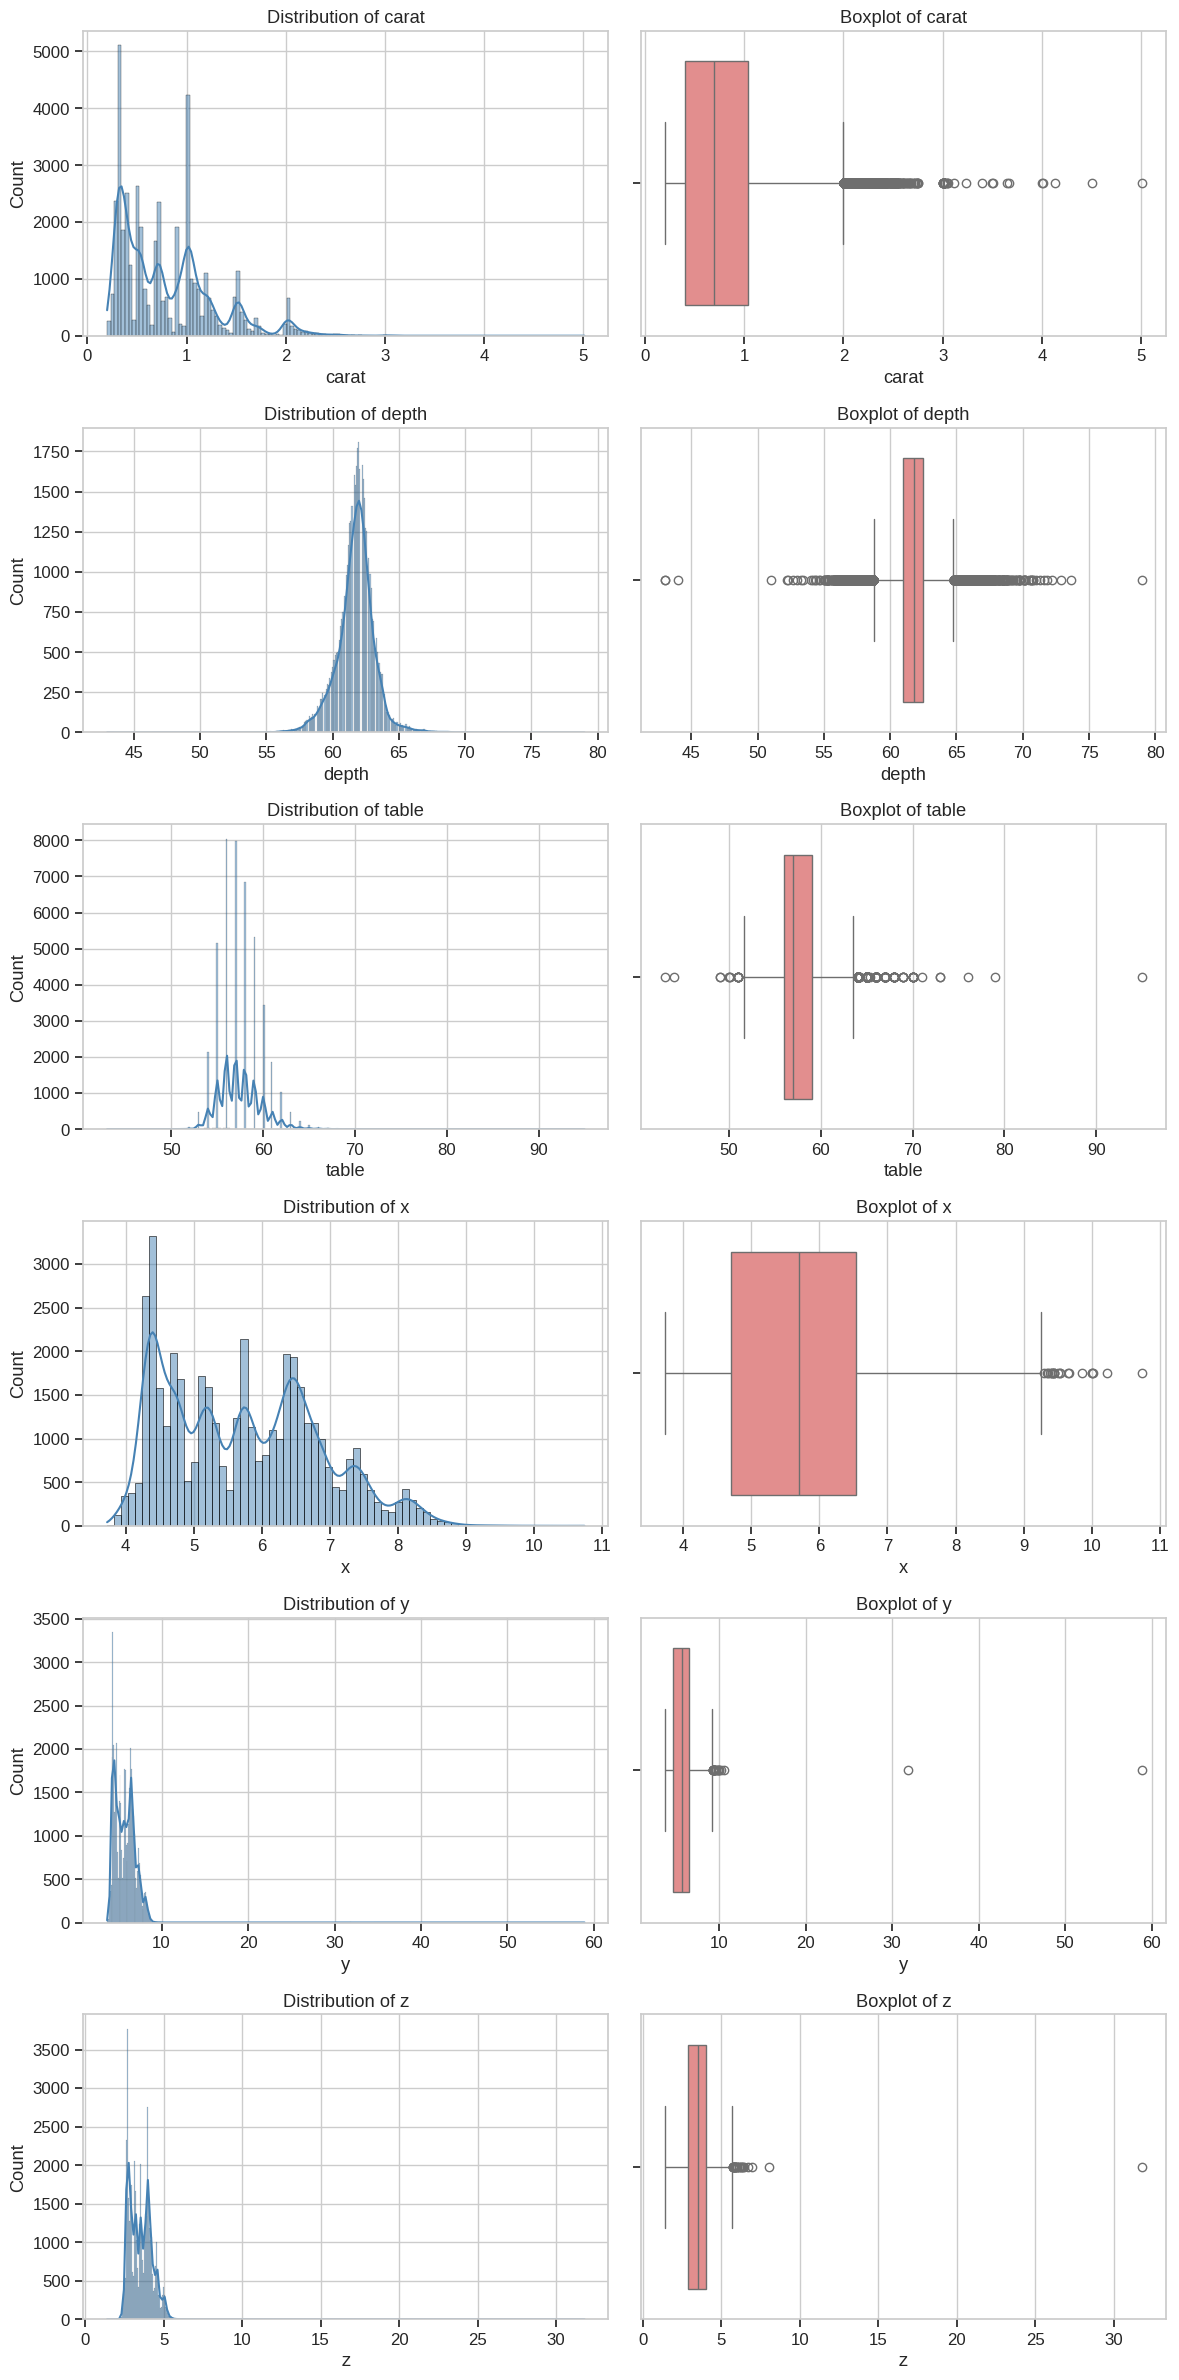

In [3]:
# ==============================================================================
# 2.A REMOVE NON-PHYSICAL DATA
# ==============================================================================
# Filter out the erroneous rows using the inverted mask
df_train_clean = df_train_clean[~errors_mask].reset_index(drop=True)
print(f"Dataset shape after removing non-physical data: {df_train_clean.shape}")

# ==============================================================================
# 2.B IDENTIFY OUTLIERS (DISTRIBUTIONS)
# ==============================================================================
def plot_distributions(df: pd.DataFrame, numerical_features: list):
    """
    Plots histograms and boxplots for numerical features to visually identify outliers.
    """
    n_features = len(numerical_features)
    fig, axes = plt.subplots(n_features, 2, figsize=(12, 4 * n_features))
    
    for i, col in enumerate(numerical_features):
        # Histogram
        sns.histplot(df[col], kde=True, ax=axes[i, 0], color='steelblue')
        axes[i, 0].set_title(f'Distribution of {col}')
        
        # Boxplot
        sns.boxplot(x=df[col], ax=axes[i, 1], color='lightcoral')
        axes[i, 1].set_title(f'Boxplot of {col}')
        
    plt.tight_layout()
    plt.show()

# Select purely numerical features for initial distribution analysis
# Excluding categorical ones (cut, color, clarity) and target (price)
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']
plot_distributions(df_train_clean, num_cols)

Total IQR-based outlier instances flagged: 4150


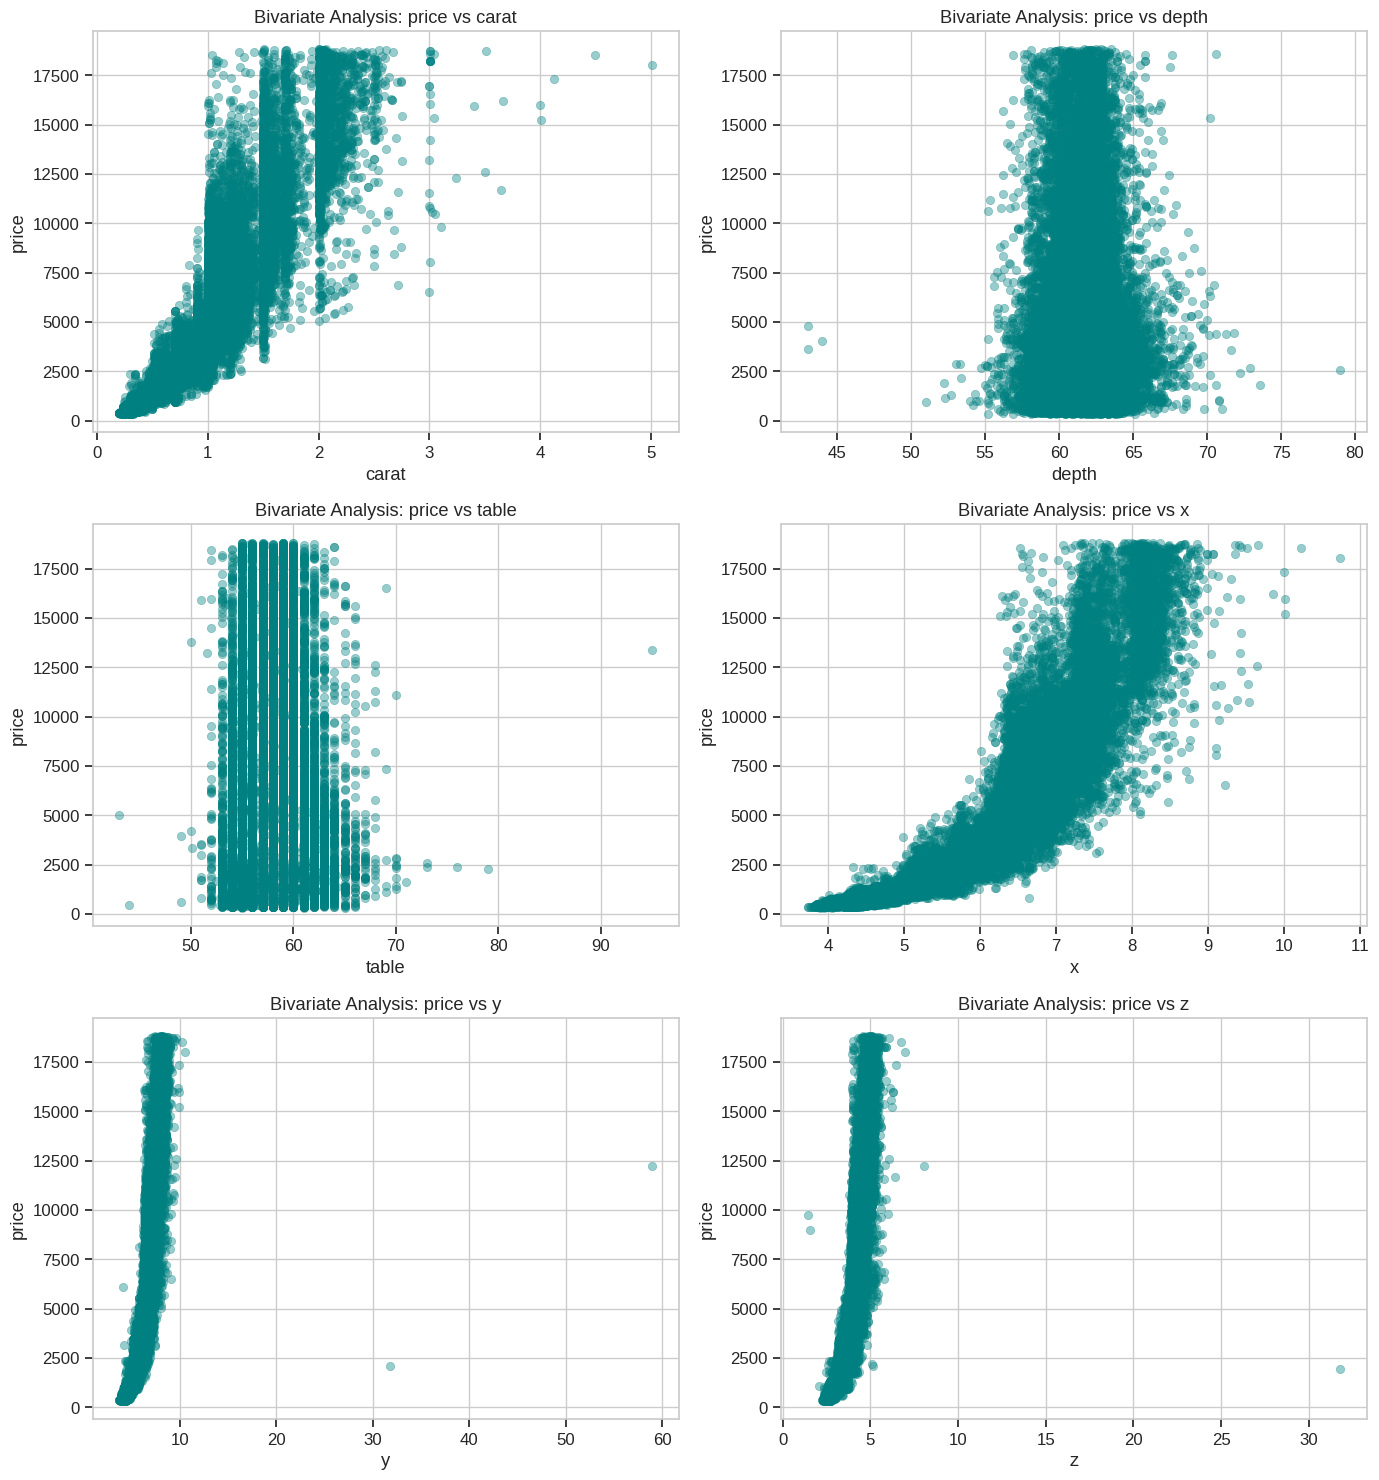

In [4]:
# ==============================================================================
# 2.B IDENTIFY OUTLIERS (IQR METHOD) & 2.D PREPARE OUTLIER TABLE
# ==============================================================================
# First, ensure the 'train_ids' series is perfectly aligned with the clean dataset
train_ids_clean = train_ids[~errors_mask].reset_index(drop=True)

outlier_records = []
num_cols = ['carat', 'depth', 'table', 'x', 'y', 'z']

#identification using Interquartile Range (IQR)
for col in num_cols:
    Q1 = df_train_clean[col].quantile(0.25)
    Q3 = df_train_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create mask for values outside the [Q1 - 1.5*IQR, Q3 + 1.5*IQR] interval
    outlier_mask = (df_train_clean[col] < lower_bound) | (df_train_clean[col] > upper_bound)
    outlier_indices = df_train_clean[outlier_mask].index
    
    # Append the findings to our tracking list
    for idx in outlier_indices:
        outlier_records.append({
            'id': train_ids_clean.iloc[idx],
            'attribute': col,
            'value': df_train_clean.loc[idx, col],
            'reason': f'Out of IQR bounds: [{lower_bound:.2f}, {upper_bound:.2f}]'
        })

# Convert to DataFrame to track all mathematical outliers
df_outliers = pd.DataFrame(outlier_records)
print(f"Total IQR-based outlier instances flagged: {len(df_outliers)}")

# ==============================================================================
# 2.C IDENTIFY OUTLIERS (ATTRIBUTE VS TARGET)
# ==============================================================================
def plot_price_scatter(df: pd.DataFrame, numerical_features: list, target: str = 'price'):
    """
    Generates scatter plots to visually identify bivariate outliers (feature vs target).
    """
    n_features = len(numerical_features)
    rows = (n_features + 1) // 2
    fig, axes = plt.subplots(rows, 2, figsize=(14, 5 * rows))
    axes = axes.flatten()
    
    for i, col in enumerate(numerical_features):
        sns.scatterplot(data=df, x=col, y=target, ax=axes[i], alpha=0.4, color='teal', edgecolor=None)
        axes[i].set_title(f'Bivariate Analysis: {target} vs {col}')
        
    # Hide any unused subplots if the number of features is odd
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
        
    plt.tight_layout()
    plt.show()

# Execute bivariate visualization
plot_price_scatter(df_train_clean, num_cols)

In [5]:
# ==============================================================================
# 2.D & 2.E: END OUTLIER TABLE AND EXECUTE HANDLING strat
# ==============================================================================

#identify bivariate extreme structural errors
bivariate_mask = (df_train_clean['y'] > 20) | (df_train_clean['z'] > 20)
bivariate_indices = df_train_clean[bivariate_mask].index

#Add them to outlier tracking table
for idx in bivariate_indices:
    outlier_records.append({
        'id': train_ids_clean.iloc[idx],
        'attribute': 'y/z',
        'value': f"y={df_train_clean.loc[idx, 'y']}, z={df_train_clean.loc[idx, 'z']}",
        'reason': 'Extreme bivariate spatial error (y or z > 20mm)'
    })

df_outliers = pd.DataFrame(outlier_records)
print(f"Total outliers tracked (Univariate + Bivariate): {len(df_outliers)}")

# Display sample of the table (combining some IQR and the Bivariate errors)
display(df_outliers)

#Drop ONLY the extreme bivariate errors
df_train_ready = df_train_clean[~bivariate_mask].reset_index(drop=True)
print(f"\nShape after dropping extreme bivariate errors: {df_train_ready.shape}")

Total outliers tracked (Univariate + Bivariate): 4153


,id,attribute,value,reason
0,79,carat,2.36,"Out of IQR bounds: [-0.56, 2.00]"
1,84,carat,2.17,"Out of IQR bounds: [-0.56, 2.00]"
2,158,carat,2.01,"Out of IQR bounds: [-0.56, 2.00]"
3,181,carat,2.02,"Out of IQR bounds: [-0.56, 2.00]"
4,205,carat,2.08,"Out of IQR bounds: [-0.56, 2.00]"
...,...,...,...,...
4148,40623,z,5.98,"Out of IQR bounds: [1.22, 5.73]"
4149,41889,z,6.03,"Out of IQR bounds: [1.22, 5.73]"
4150,10263,y/z,"y=5.15, z=31.8",Extreme bivariate spatial error (y or z > 20mm)
4151,19146,y/z,"y=58.9, z=8.06",Extreme bivariate spatial error (y or z > 20mm)



Shape after dropping extreme bivariate errors: (43981, 10)


In [6]:
# ==============================================================================
# 2.F ORDINAL ENCODING OF CATEGORICAL VARIABLES
# ==============================================================================
from sklearn.preprocessing import StandardScaler

# Define dictionaries based on the semantic order provided
cut_map = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_map = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_map = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}

df_train_ready['cut'] = df_train_ready['cut'].map(cut_map)
df_train_ready['color'] = df_train_ready['color'].map(color_map)
df_train_ready['clarity'] = df_train_ready['clarity'].map(clarity_map)

# ==============================================================================
# 2.G STANDARDIZATION OF ATTRIBUTES (except X, Y, Z, PRICE)
# ==============================================================================
cols_to_standardize = ['carat', 'depth', 'table', 'cut', 'color', 'clarity']
scaler = StandardScaler()

#apply standard scaling
df_train_ready[cols_to_standardize] = scaler.fit_transform(df_train_ready[cols_to_standardize])

# ==============================================================================
# 2.H JOINT MIN-MAX SCALING FOR X, Y, Z [-1, 1]
# ==============================================================================
#find global min and max across all three spatial dimensions
global_min = df_train_ready[['x', 'y', 'z']].min().min()
global_max = df_train_ready[['x', 'y', 'z']].max().max()

#apply joint scaling formula: 2 * (val - min) / (max - min) - 1
for col in ['x', 'y', 'z']:
    df_train_ready[col] = 2 * ((df_train_ready[col] - global_min) / (global_max - global_min)) - 1

# ==============================================================================
# 2.I LOG TRANSFORMATION AND [0.1, 0.9] SCALING OF TARGET
# ==============================================================================
#calc logarithm
log_price_raw = np.log(df_train_ready['price'])

# Min-Max Scaling to [0.1, 0.9]
min_log = log_price_raw.min()
max_log = log_price_raw.max()

df_train_ready['log_price'] = 0.1 + 0.8 * ((log_price_raw - min_log) / (max_log - min_log))

# ==============================================================================
# 2.J CREATE BINARY CLASSIFICATION TARGET
# ==============================================================================
df_train_ready['high_price'] = (df_train_ready['price'] >= 2500).astype(int)


print("Pre-processing complete. Final dataset sample:")
display(df_train_ready)

Pre-processing complete. Final dataset sample:


,carat,cut,color,clarity,depth,table,x,y,z,price,log_price,high_price
0,-0.565350,-0.809650,1.522764,-0.033634,1.013088,-0.649353,-0.209003,-0.198285,-0.607717,1601,0.413928,0
1,-1.008897,0.084807,-0.827918,-0.033634,0.453710,0.246672,-0.367631,-0.374062,-0.721329,648,0.235513,0
2,-0.079559,0.979263,-1.415588,-0.639886,0.034177,-0.201340,-0.039657,-0.052519,-0.526259,2399,0.493702,0
3,0.448473,-1.704107,-0.827918,-0.033634,-0.665046,1.590710,0.076099,0.091104,-0.459807,5229,0.647397,1
4,-0.142923,0.979263,-1.415588,0.572618,0.243943,-1.545378,-0.065380,-0.058950,-0.532690,2167,0.473640,0
...,...,...,...,...,...,...,...,...,...,...,...,...
43976,0.237260,-0.809650,-0.240247,0.572618,-0.595124,-1.545378,0.041801,0.065380,-0.476956,4590,0.621687,1
43977,-1.030018,0.084807,1.522764,0.572618,-1.504114,0.246672,-0.356913,-0.363344,-0.740622,877,0.295205,0
43978,-0.839927,-1.704107,-1.415588,-0.639886,1.502544,-0.201340,-0.294748,-0.303323,-0.661308,765,0.268254,0
43979,1.504539,0.084807,0.347423,-0.033634,0.174021,2.038723,0.273312,0.247588,-0.333333,13771,0.838407,1


In [7]:
output_path = '/home/jovyan/work/data/diamonds-train-preprocessed.csv'
df_train_ready.to_csv(output_path, index=False)
print(f"Preprocessed training data successfully saved to: {output_path}")

#store the transformation parameters needed for the test set
transformation_params = {
    'scaler': scaler,  #fitted StandardScaler object
    'spatial_min': global_min,
    'spatial_max': global_max,
    'log_price_min': min_log,
    'log_price_max': max_log,
    'cut_map': cut_map,
    'color_map': color_map,
    'clarity_map': clarity_map
}

Preprocessed training data successfully saved to: /home/jovyan/work/data/diamonds-train-preprocessed.csv


In [8]:
def preprocess_test_data(df_test_raw, params):
    """
    Applies the exact same transformations to the test set using parameters 
    learned from the training set to prevent data leakage.
    """
    # Drop 'id' and create a working copy
    df_test = df_test_raw.copy()
    test_ids = df_test['id']
    df_test = df_test.drop(columns=['id'])

    # Ordinal Encoding, using the same maps
    df_test['cut'] = df_test['cut'].map(params['cut_map'])
    df_test['color'] = df_test['color'].map(params['color_map'])
    df_test['clarity'] = df_test['clarity'].map(params['clarity_map'])

    # Standardization (using the FITTED scaler from training)
    cols_to_std = ['carat', 'depth', 'table', 'cut', 'color', 'clarity']
    df_test[cols_to_std] = params['scaler'].transform(df_test[cols_to_std])

    # Joint spatial scaling [-1, 1] (using training min/max)
    s_min, s_max = params['spatial_min'], params['spatial_max']
    for col in ['x', 'y', 'z']:
        df_test[col] = 2 * ((df_test[col] - s_min) / (s_max - s_min)) - 1

    # Target transformations: log_price and high_price
    #price is the target, transform it only to evaluate later
    log_p = np.log(df_test['price'])
    p_min, p_max = params['log_price_min'], params['log_price_max']
    df_test['log_price'] = 0.1 + 0.8 * ((log_p - p_min) / (p_max - p_min))

    df_test['high_price'] = (df_test['price'] >= 2500).astype(int)

    return df_test, test_ids

#load raw test data
df_test_raw = pd.read_csv('/home/jovyan/work/data/diamonds-test.csv')

# Process it using the stored parameters
df_test_ready, test_ids = preprocess_test_data(df_test_raw, transformation_params)

print(f"Test set preprocessed successfully. Shape: {df_test_ready.shape}")
display(df_test_ready)

output_path2 = '/home/jovyan/work/data/diamonds-test-ready.csv'
df_test_ready.to_csv(output_path2, index=False)
print(f"Test preprocessed set data successfully saved to: {output_path2}")

Test set preprocessed successfully. Shape: (9940, 12)


,carat,cut,color,clarity,depth,table,x,y,z,price,log_price,high_price
0,0.617444,0.979263,-0.240247,1.178870,0.523632,-0.649353,0.099678,0.108253,-0.423365,8282,0.738107,1
1,-0.206287,-0.809650,0.347423,-0.639886,-1.364269,1.142698,-0.069668,-0.052519,-0.560557,2196,0.476262,0
2,2.560604,-1.704107,-1.415588,-0.639886,-2.063492,1.142698,0.470525,0.453376,-0.264737,16731,0.876813,1
3,-1.114504,0.979263,0.347423,2.391375,0.034177,-1.097366,-0.414791,-0.399786,-0.751340,760,0.266960,0
4,-0.544228,0.084807,1.522764,-0.639886,0.383788,1.142698,-0.183280,-0.191854,-0.607717,1715,0.427496,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9935,3.870125,0.979263,-2.003259,-1.246138,0.243943,-0.201340,0.590568,0.601286,-0.123258,16914,0.878958,1
9936,0.638565,0.979263,0.347423,1.178870,-0.385357,-0.649353,0.129689,0.123258,-0.427653,9817,0.771647,1
9937,3.067515,0.979263,-1.415588,-1.246138,-0.734968,-0.649353,0.528403,0.519829,-0.193998,11104,0.795947,1
9938,0.469595,-0.809650,0.935094,2.391375,1.222855,0.246672,0.076099,0.054662,-0.434084,10710,0.788820,1


Test preprocessed set data successfully saved to: /home/jovyan/work/data/diamonds-test-ready.csv


In [9]:
# ==============================================================================
# MERGE PHASE: PREPARING MATRICES FOR DEV MODELS
# ==============================================================================

# 1. Define Features (X) and Target (y) for TRAINING
# drop all target-related columns to prevent data leakage
# models must predict based solely on physical and categorical attributes
features_to_drop = ['price', 'log_price', 'high_price']

X_train = df_train_ready.drop(columns=features_to_drop)
y_train = df_train_ready['log_price'] #target is strictly the scaled logarithm [0.1, 0.9]

# 2. Define Features (X) and Target (y) for TESTING
X_test = df_test_ready.drop(columns=features_to_drop)
y_test_scaled = df_test_ready['log_price']

# 3. Prepare external variables needed by evaluation functions
# df_test_original must contain the raw unscaled test data for the final DataFrame assembly
df_test_original = pd.read_csv('/home/jovyan/work/data/diamonds-test.csv')

#extract the scaling parameters from previous dictionary
min_log_price = transformation_params['log_price_min']
max_log_price = transformation_params['log_price_max']

print(f"Feature Matrix X_train shape: {X_train.shape}")
print(f"Target Vector y_train shape: {y_train.shape}")
print("Data is correctly decoupled and ready for modeling.")

Feature Matrix X_train shape: (43981, 9)
Target Vector y_train shape: (43981,)
Data is correctly decoupled and ready for modeling.


In [10]:
# FUNCTIONS
def inverse_transform_price(scaled_preds, min_log_price, max_log_price):
    """
    Reverses the linear scaling [0.1, 0.9] and the logarithm to return to USD ($).
    """
    # 1. Reverse the min-max scaling to [0.1, 0.9]
    # Formula: S = 0.1 + 0.8 * (x - min) / (max - min)
    # Solving for x: x = min + (S - 0.1) * (max - min) / 0.8
    log_price_preds = min_log_price + ((scaled_preds - 0.1) * (max_log_price - min_log_price) / 0.8)
    
    # 2. Reverse the logarithm (exponential function)
    usd_preds = np.exp(log_price_preds)
    
    return usd_preds

def calculate_mape(y_true_usd, y_pred_usd):
    """
    Calculates the exact mathematical Mean Absolute Percentage Error (MAPE).
    Both inputs must already be in USD.
    """
    #avoid division by zero just in case (although prices start at $326)
    epsilon = 1e-10 
    mape = 100 * np.mean(np.abs((y_pred_usd - y_true_usd) / (y_true_usd + epsilon)))
    return mape

class LocalKernelRegression(BaseEstimator, RegressorMixin):
    """
    Custom Scikit-Learn compatible estimator for Local Kernel Regression 
    using Nadaraya-Watson and an RBF Kernel.
    """
    def __init__(self, gamma=1.0):
        self.gamma = gamma # Bandwidth similar diamonds
        
    def fit(self, X, y):
        self.X_train_ = np.array(X)
        self.y_train_ = np.array(y)
        return self
        
    def predict(self, X):
        X = np.array(X)
        
        # Calculate the weight matrix using a Gaussian (RBF) kernel
        weights = rbf_kernel(X, self.X_train_, gamma=self.gamma)
        
        # Nadaraya-Watson prediction: weighted sum of y_train
        # Avoid division by zero by adding a small epsilon to the denominator
        sum_weights = np.sum(weights, axis=1) + 1e-10
        y_pred = np.dot(weights, self.y_train_) / sum_weights
        
        return y_pred

def build_grid_searches():
    """
    Prepares and returns the GridSearchCV objects for each model.
    """
    # 1. k-Nearest Neighbors (k-NN)
    knn_params = {
        'n_neighbors': [14, 15, 16],
        'weights': ['distance'], #Uniform: all neighbors contribute the same | Distance: near neighbors contribute more
        'p': [1, 2], # Manhattan (grid path) vs Euclidean distance (straight)
        'algorithm': ['auto']
    }
    knn_grid = GridSearchCV(KNeighborsRegressor(), knn_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

    # 2. Local Kernel Regression (LKR)
    lkr_params = {
        'gamma': [10.1, 10.2, 10.5, 15]
    }
    lkr_grid = GridSearchCV(LocalKernelRegression(), lkr_params, cv=5, scoring='neg_mean_squared_error', n_jobs=4)

    # 3. Multilayer Neural Network (MLNN-BP)
    mlnn_params = {
        'hidden_layer_sizes': [(64, 64), (32, 64), (128, 64, 32), (128, 32), (128, 64)],
        'activation': ['relu'],
        'alpha': [0.001, 0.0014, 0.0015, 0.0016],
        'max_iter': [800]
    }
    # Using early_stopping to prevent overfitting during Cross-Validation
    mlnn_grid = GridSearchCV(MLPRegressor(early_stopping=True, random_state=42), 
                             mlnn_params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)

    # 4. Multilinear Regression (MLR)
    mlr_grid = LinearRegression()

    return {
        'MLR': mlr_grid,
        'k-NN': knn_grid,
        'LKR': lkr_grid,
        'MLNN-BP': mlnn_grid
    }

In [11]:
# ==============================================================================
# Model Training and Hyperparameter Optimization Phase
# ==============================================================================

# 1. Retrieve the dictionary of uninitialized models and GridSearch objects
grids = build_grid_searches()

print("Initiating model training and cross-validation process...\n" + "="*60)

# 2. Iterate through each configured algorithm in the dictionary
for model_name, grid_search_obj in grids.items():
    print(f"Fitting {model_name}...")
    print("Computing... Please wait.")
    
    # Fit the model using the training features and the target variable.
    # For GridSearchCV objects, this step automatically performs k-fold 
    # cross-validation across all specified hyperparameter combinations.
    grid_search_obj.fit(X_train, y_train)
    
    # Check if the fitted object contains optimized hyperparameters 
    # (Standard MLR will not, as it calculates coefficients directly)
    if hasattr(grid_search_obj, 'best_params_'):
        print(f"[✓] {model_name} successfully trained.")
        print(f"    Optimal hyperparameters found: {grid_search_obj.best_params_}")
        print(f"    Best CV validation score: {grid_search_obj.best_score_:.4f}\n")
    else:
        print(f"[✓] {model_name} successfully trained.")
        print(f"    (Direct OLS mathematical fit; no hyperparameters tuned)\n")

print("="*60)
print("SUCCESS: All predictive models have been fitted to the training set.")

Initiating model training and cross-validation process...
Fitting MLR...
Computing... Please wait.
[✓] MLR successfully trained.
    (Direct OLS mathematical fit; no hyperparameters tuned)

Fitting k-NN...
Computing... Please wait.
[✓] k-NN successfully trained.
    Optimal hyperparameters found: {'algorithm': 'auto', 'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
    Best CV validation score: -0.0008

Fitting LKR...
Computing... Please wait.
[✓] LKR successfully trained.
    Optimal hyperparameters found: {'gamma': 10.1}
    Best CV validation score: -0.0018

Fitting MLNN-BP...
Computing... Please wait.
[✓] MLNN-BP successfully trained.
    Optimal hyperparameters found: {'activation': 'relu', 'alpha': 0.0015, 'hidden_layer_sizes': (128, 64, 32), 'max_iter': 800}
    Best CV validation score: -0.0004

SUCCESS: All predictive models have been fitted to the training set.


In [12]:
def evaluate_and_visualize(models_dict, X_test, y_test_scaled, df_test_original, min_log, max_log):
    """
    Performs predictions, inverts the scale, calculates MAPE, creates the DataFrame, and visualizes.
    - y_test_scaled: The scaled real prices [0.1, 0.9].
    - df_test_original: The DataFrame with the original test set features.
    """
    # 1. Invert the real test target to USD to correctly calculate MAPE
    y_test_usd = inverse_transform_price(y_test_scaled, min_log, max_log)
    
    # Prepare the results DataFrame with a copy of the original dataset
    df_results = df_test_original.copy()
    
    mapes = {}
    preds_usd_dict = {}
    
    # 2. Make predictions and calculate metrics
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()
    
    # Column names exactly as requested in the assignment (section 3.f.ii)
    column_mapping = {
        'MLR': 'pred_price_mlr',
        'k-NN': 'pred_price_knn',
        'MLNN-BP': 'pred_price_bp',
        'LKR': 'pred_price_lkr' # Not explicitly asked in 3.f.ii, but added for completeness
    }
    
    for idx, (name, model) in enumerate(models_dict.items()):
        # Prediction (returns values in [0.1, 0.9] scale)
        pred_scaled = model.predict(X_test)
        
        # Inverse transformation to USD
        pred_usd = inverse_transform_price(pred_scaled, min_log, max_log)
        preds_usd_dict[name] = pred_usd
        
        # Add to the final DataFrame
        col_name = column_mapping.get(name, f'pred_price_{name.lower()}')
        df_results[col_name] = pred_usd
        
        # Calculate MAPE
        current_mape = calculate_mape(y_test_usd, pred_usd)
        mapes[name] = current_mape
        print(f"MAPE for {name}: {current_mape:.4f}%")
        
        # 3. Scatter Plot (Real vs Predicted)
        ax = axes[idx]
        ax.scatter(y_test_usd, pred_usd, alpha=0.3, color='blue', edgecolor='k', s=15)
        
        # Ideal line (y = x)
        max_val = max(np.max(y_test_usd), np.max(pred_usd))
        ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Prediction (y=x)')
        
        ax.set_title(f'{name} - Real vs Predicted (MAPE: {current_mape:.2f}%)')
        ax.set_xlabel('Real Price (USD)')
        ax.set_ylabel('Predicted Price (USD)')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
    
    # Return the exact DataFrame required by the assignment
    return df_results, mapes



Iniciando la evaluación final con el conjunto de Test...

MAPE for MLR: 11.6252%
MAPE for k-NN: 10.2642%
MAPE for LKR: 12.9909%
MAPE for MLNN-BP: 7.9952%


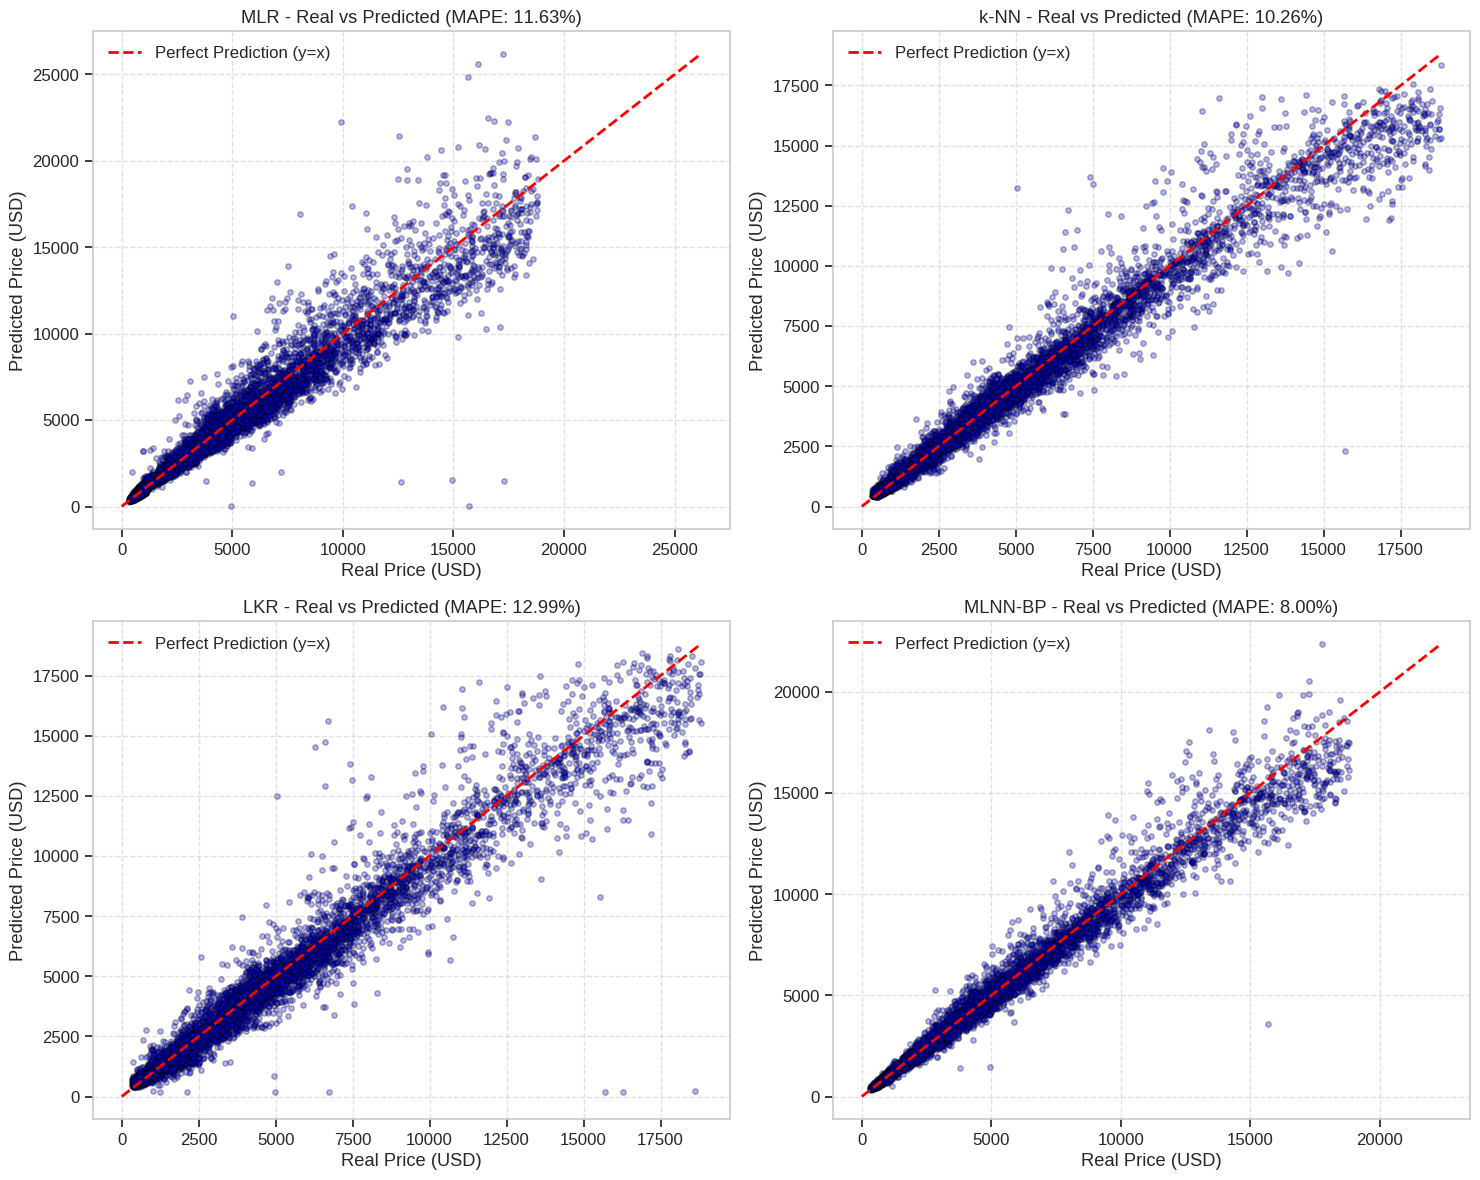


¡Evaluación completada!


,id,carat,cut,color,clarity,depth,table,x,y,z,price,pred_price_mlr,pred_price_knn,pred_price_lkr,pred_price_bp
0,44001,1.09,Ideal,G,VVS2,62.5,56.0,6.54,6.58,4.10,8282,7445.819611,8695.016181,8721.561360,8358.576820
1,44002,0.70,Very Good,F,SI1,59.8,60.0,5.75,5.83,3.46,2196,2353.899389,2402.023245,2511.921724,2362.921126
2,44003,2.01,Good,I,SI1,58.8,60.0,8.27,8.19,4.84,16731,13006.599631,14339.042748,17095.263131,14129.766187
3,44004,0.27,Ideal,F,IF,61.8,55.0,4.14,4.21,2.57,760,777.481282,840.816074,984.559114,794.745929
4,44005,0.54,Premium,D,SI1,62.3,60.0,5.22,5.18,3.24,1715,1717.013737,1388.084087,1304.743489,1643.594308
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9935,53936,2.63,Ideal,J,SI2,62.1,57.0,8.83,8.88,5.50,16914,17547.375331,15855.023417,15802.463865,16184.107841
9936,53937,1.10,Ideal,F,VVS2,61.2,56.0,6.68,6.65,4.08,9817,8552.771968,9579.150704,9385.272146,10027.074061
9937,53938,2.25,Ideal,I,SI2,60.7,56.0,8.54,8.50,5.17,11104,16038.097274,15048.511049,15763.231101,14961.411500
9938,53939,1.02,Very Good,E,IF,63.5,58.0,6.43,6.33,4.05,10710,9646.095783,10302.984742,11282.175647,11860.119570


In [13]:
# ==============================================================================
# 3.e y 3.f - Evaluación Final y Visualización de Resultados
# ==============================================================================

print("Iniciando la evaluación final con el conjunto de Test...\n")

# Llamamos a la función pasándole nuestros modelos entrenados y los datos de test
df_resultados_finales, resultados_mape = evaluate_and_visualize(
    models_dict=grids,               # Tu diccionario de modelos ya entrenados
    X_test=X_test,                   # Las características del set de test
    y_test_scaled=y_test_scaled,     # Los precios reales del test (escalados)
    df_test_original=df_test_original, # El dataframe original de test
    min_log=min_log,                 # El valor mínimo del logaritmo (de tu compañero)
    max_log=max_log                  # El valor máximo del logaritmo (de tu compañero)
)

print("\n¡Evaluación completada!")

# Mostramos las primeras 5 filas del dataframe para comprobar que se han 
# añadido correctamente las columnas pred_price_mlr, pred_price_knn, etc.
df_resultados_finales